# Air Quality and Socioeconomic Analysis across Indian States
### Using CPCB Real-Time AQI Data and NFHS-5 Health Survey Data
**Authors:** Sayon Mitra  
**Data Sources:** data.gov.in – CPCB AQI Dataset | NFHS-5 (National Family Health Survey-5)  
**Objective:** Analyse the distribution of key air pollutants across Indian states, identify socioeconomic correlates of pollution exposure, build predictive models, and cluster states by pollution-vulnerability profiles.

## 1. Environment Setup

In [ ]:
# ── Standard library imports ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print('All libraries loaded successfully.')

## 2. Data Loading
Two datasets are used:
- **aqi.csv** – Real-time pollutant readings from CPCB monitoring stations across India.
- **health.xls** – State-level socioeconomic and health indicators from NFHS-5 (2019-21).

In [2]:
# Load AQI dataset
aqi_df = pd.read_csv('aqi.csv')
aqi_df['last_update'] = pd.to_datetime(aqi_df['last_update'], dayfirst=True, errors='coerce')

# Load health/socioeconomic dataset
health_df = pd.read_excel('health.xls', header=0)

print(f'AQI dataset    : {aqi_df.shape[0]:,} rows × {aqi_df.shape[1]} columns')
print(f'Health dataset : {health_df.shape[0]:,} rows × {health_df.shape[1]} columns')

AQI dataset    : 3,411 rows × 11 columns
Health dataset : 111 rows × 136 columns


## 3. Data Understanding & Quality Check

In [3]:
print('=== AQI Dataset — First 5 Rows ===')
aqi_df.head()

=== AQI Dataset — First 5 Rows ===


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",2026-03-27 08:00:00,27.10,93.68,PM10,29.00,152.00,78.00
1,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",2026-03-27 08:00:00,27.10,93.68,NO2,7.00,7.00,7.00
2,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",2026-03-27 08:00:00,27.10,93.68,NH3,1.00,1.00,1.00
3,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2026-03-27 08:00:00,26.07,91.87,PM10,68.00,161.00,96.00
4,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2026-03-27 08:00:00,26.07,91.87,SO2,18.00,32.00,31.00


In [4]:
print('=== Health Dataset — First 3 Rows (first 8 columns) ===')
health_df.iloc[:3, :8]

=== Health Dataset — First 3 Rows (first 8 columns) ===


,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)"
0,India,Urban,160138,179535,26420,82.51,23.14,985.28
1,India,Rural,476561,544580,75419,66.77,28.10,1037.29
2,India,Total,636699,724115,101839,71.76,26.52,1020.45


In [5]:
print('AQI — Missing Values per Column:')
print(aqi_df.isnull().sum())
print()
print('Health — Missing Values per Column (non-zero only):')
mv = health_df.isnull().sum()
print(mv[mv > 0].to_string() if mv[mv > 0].shape[0] else 'None')

AQI — Missing Values per Column:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    138
pollutant_max    138
pollutant_avg    138
dtype: int64

Health — Missing Values per Column (non-zero only):
None


In [6]:
print('AQI — Pollutants covered:', sorted(aqi_df['pollutant_id'].unique()))
print('AQI — States covered    :', aqi_df['state'].nunique())
print('AQI — Cities covered    :', aqi_df['city'].nunique())
print('AQI — Stations covered  :', aqi_df['station'].nunique())

AQI — Pollutants covered: ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']
AQI — States covered    : 31
AQI — Cities covered    : 267
AQI — Stations covered  : 511


## 4. Data Cleaning
### 4.1 AQI Data
- Drop rows with missing `pollutant_avg` (138 of 3,411; ~4%).
- Harmonise state names to lowercase, replacing underscores with spaces for consistent merging.
- Map `tamilnadu` → `tamil nadu` to align with NFHS spelling.

In [ ]:
# Drop rows with missing pollutant readings
aqi_df = aqi_df.dropna(subset=['pollutant_avg']).copy()

# Normalise state names: lowercase, strip, replace underscores with spaces
aqi_df['state_norm'] = (
    aqi_df['state']
    .str.lower()
    .str.strip()
    .str.replace('_', ' ', regex=False)
)
# Fix inconsistent CPCB spelling for Tamil Nadu
aqi_df['state_norm'] = aqi_df['state_norm'].replace({'tamilnadu': 'tamil nadu'})

print(f'Rows after cleaning : {len(aqi_df):,}')
print(f'Unique states (CPCB): {aqi_df["state_norm"].nunique()}')

### 4.2 Health Data
- Retain only 'Total' rows (combined urban + rural figures).
- Normalise state names for merging.
- Manual name harmonisation to align CPCB and NFHS state naming conventions (e.g., "NCT of Delhi" → "delhi", "Maharastra" → "maharashtra", "&" → "and").

In [ ]:
# Keep only 'Total' (combined urban+rural) rows
health_total = health_df[health_df['Area'] == 'Total'].copy()

# Normalise state names
health_total['state_norm'] = (
    health_total['States/UTs']
    .str.lower()
    .str.strip()
)

# Manual name harmonisation (NFHS → CPCB/common conventions)
name_map = {
    'nct of delhi'             : 'delhi',
    'maharastra'               : 'maharashtra',
    'andaman & nicobar islands': 'andaman and nicobar',
    'jammu & kashmir'          : 'jammu and kashmir',
}
health_total['state_norm'] = health_total['state_norm'].replace(name_map)

print(f'States/UTs in health dataset (Total rows): {len(health_total)}')

## 5. State-Level Aggregation and Dataset Merge

In [ ]:
# Aggregate AQI: mean pollutant_avg per state
aqi_state = (
    aqi_df
    .groupby('state_norm', as_index=False)['pollutant_avg']
    .mean()
    .rename(columns={'pollutant_avg': 'mean_pollutant_avg'})
)

# Per-pollutant mean per state (for richer analysis)
aqi_pivot = (
    aqi_df
    .groupby(['state_norm', 'pollutant_id'])['pollutant_avg']
    .mean()
    .unstack(level='pollutant_id')
    .reset_index()
)
aqi_pivot.columns.name = None

# Merge AQI state averages with health indicators
merged_df = pd.merge(aqi_state, health_total, on='state_norm', how='inner')
merged_df = merged_df.drop(columns=['Area', 'Number of Households surveyed'], errors='ignore')
merged_df = merged_df.reset_index(drop=True)

print(f'Merged dataset shape: {merged_df.shape}')
print(f'States matched      : {len(merged_df)} (target: 29)')
print('States:', merged_df['state_norm'].tolist())

## 6. Descriptive Statistics
### 6.1 Pollutant-Level Summary (All Monitoring Stations)

In [10]:
pollutant_stats = (
    aqi_df
    .groupby('pollutant_id')['pollutant_avg']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
    .rename(columns={'count': 'n', 'mean': 'Mean', 'median': 'Median',
                     'std': 'SD', 'min': 'Min', 'max': 'Max'})
)
print('=== Pollutant Statistics (µg/m³ or ppb) ===')
pollutant_stats

=== Pollutant Statistics (µg/m³ or ppb) ===


,n,Mean,Median,SD,Min,Max
pollutant_id,,,,,,
CO,477,35.91,32.00,22.26,2.00,131.00
NH3,427,6.16,5.00,4.67,1.00,44.00
NO2,481,29.22,24.00,21.64,1.00,138.00
OZONE,459,21.95,18.00,15.87,1.00,143.00
PM10,482,96.11,91.00,38.07,23.00,268.00
PM2.5,486,76.60,65.00,41.30,2.00,243.00
SO2,461,16.98,13.00,14.93,1.00,111.00


### 6.2 State-Level Pollution Summary

In [11]:
state_stats = (
    aqi_df
    .groupby('state_norm')['pollutant_avg']
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'Mean Pollutant Avg', 'std': 'SD',
                     'min': 'Min', 'max': 'Max'})
)
print('=== State-Level Pollution Summary (top 15) ===')
state_stats.head(15)

=== State-Level Pollution Summary (top 15) ===


,Mean Pollutant Avg,SD,Min,Max
state_norm,,,,
delhi,64.55,55.28,2.00,217.00
himachal pradesh,61.29,53.55,4.00,155.00
tripura,53.00,75.83,2.00,183.00
jharkhand,52.75,50.87,3.00,130.00
haryana,48.24,54.27,1.00,243.00
odisha,46.27,48.96,1.00,218.00
gujarat,44.59,38.37,2.00,151.00
punjab,43.74,38.45,2.00,170.00
uttar_pradesh,43.58,42.70,1.00,244.00


### 6.3 AQI Category Classification
Using CPCB AQI sub-index thresholds: Good (0–50), Satisfactory (51–100), Moderate (101–200), Poor (201–300), Very Poor (301–400), Severe (> 400).

In [12]:
def classify_aqi(val):
    if   val <= 50:  return 'Good'
    elif val <= 100: return 'Satisfactory'
    elif val <= 200: return 'Moderate'
    elif val <= 300: return 'Poor'
    elif val <= 400: return 'Very Poor'
    else:            return 'Severe'

aqi_df['aqi_category'] = aqi_df['pollutant_avg'].apply(classify_aqi)

cat_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_counts = (
    aqi_df['aqi_category']
    .value_counts()
    .reindex(cat_order, fill_value=0)
)
cat_pct = (cat_counts / cat_counts.sum() * 100).round(1)
cat_summary = pd.DataFrame({'Count': cat_counts, 'Percentage (%)': cat_pct})
print('=== AQI Category Distribution ===')
cat_summary

=== AQI Category Distribution ===


,Count,Percentage (%)
aqi_category,,
Good,2268,69.30
Satisfactory,687,21.00
Moderate,299,9.10
Poor,19,0.60
Very Poor,0,0.00
Severe,0,0.00


## 7. Exploratory Data Analysis – Visualisations

### 7.1 Distribution of Average Pollutant Levels

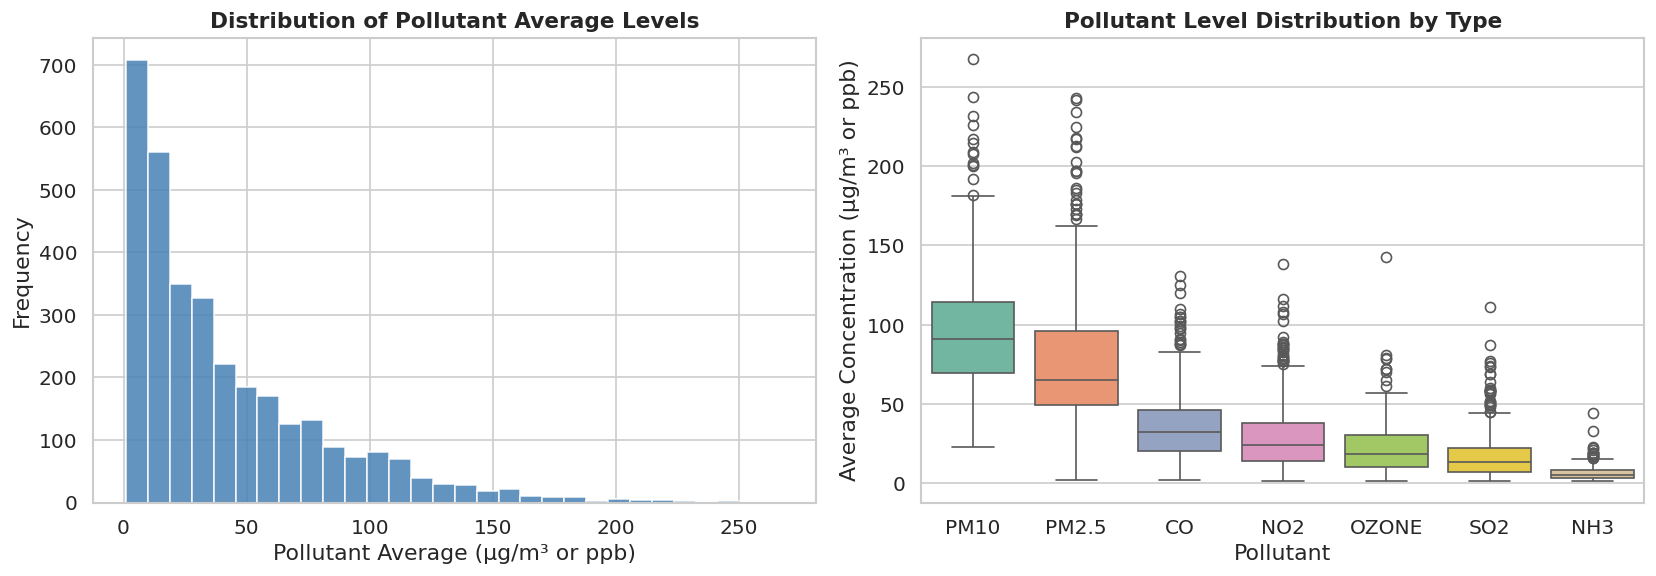

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(aqi_df['pollutant_avg'].dropna(), bins=30, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Pollutant Average Levels', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pollutant Average (µg/m³ or ppb)')
axes[0].set_ylabel('Frequency')

# Box-plot per pollutant
order = aqi_df.groupby('pollutant_id')['pollutant_avg'].median().sort_values(ascending=False).index
sns.boxplot(data=aqi_df, x='pollutant_id', y='pollutant_avg',
            order=order, palette='Set2', ax=axes[1])
axes[1].set_title('Pollutant Level Distribution by Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pollutant')
axes[1].set_ylabel('Average Concentration (µg/m³ or ppb)')

plt.tight_layout()
plt.savefig('fig1_pollutant_distribution.png', bbox_inches='tight')
plt.show()

### 7.2 Top 15 Most Polluted States

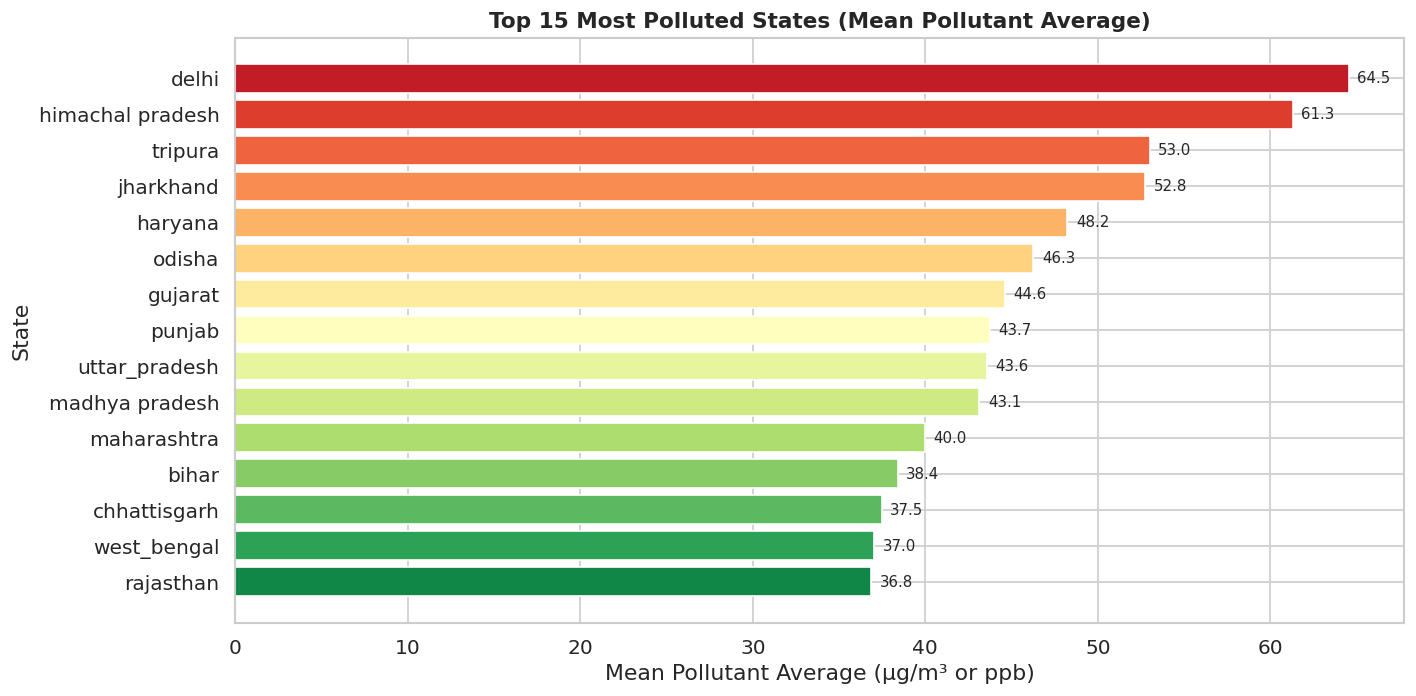

In [14]:
top15 = state_stats.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('RdYlGn_r', len(top15))
bars = ax.barh(top15.index[::-1], top15['Mean Pollutant Avg'][::-1], color=colors)
ax.set_title('Top 15 Most Polluted States (Mean Pollutant Average)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Pollutant Average (µg/m³ or ppb)')
ax.set_ylabel('State')
for bar, val in zip(bars, top15['Mean Pollutant Avg'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_top_polluted_states.png', bbox_inches='tight')
plt.show()

### 7.3 AQI Category Distribution

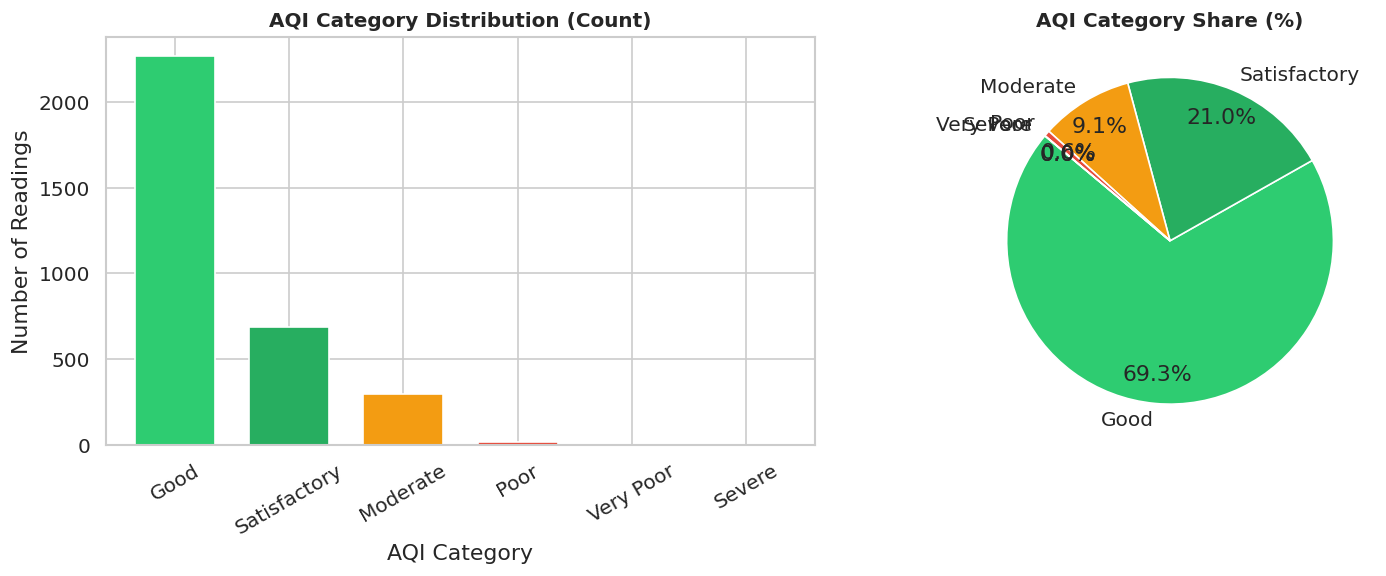

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#8e44ad', '#2c3e50']
cat_counts.plot(kind='bar', ax=axes[0], color=palette, edgecolor='white', width=0.7)
axes[0].set_title('AQI Category Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('AQI Category')
axes[0].set_ylabel('Number of Readings')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(cat_counts, labels=cat_counts.index, colors=palette,
            autopct='%1.1f%%', startangle=140, pctdistance=0.82)
axes[1].set_title('AQI Category Share (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_aqi_categories.png', bbox_inches='tight')
plt.show()

### 7.4 Per-Pollutant Mean by State (Heatmap)

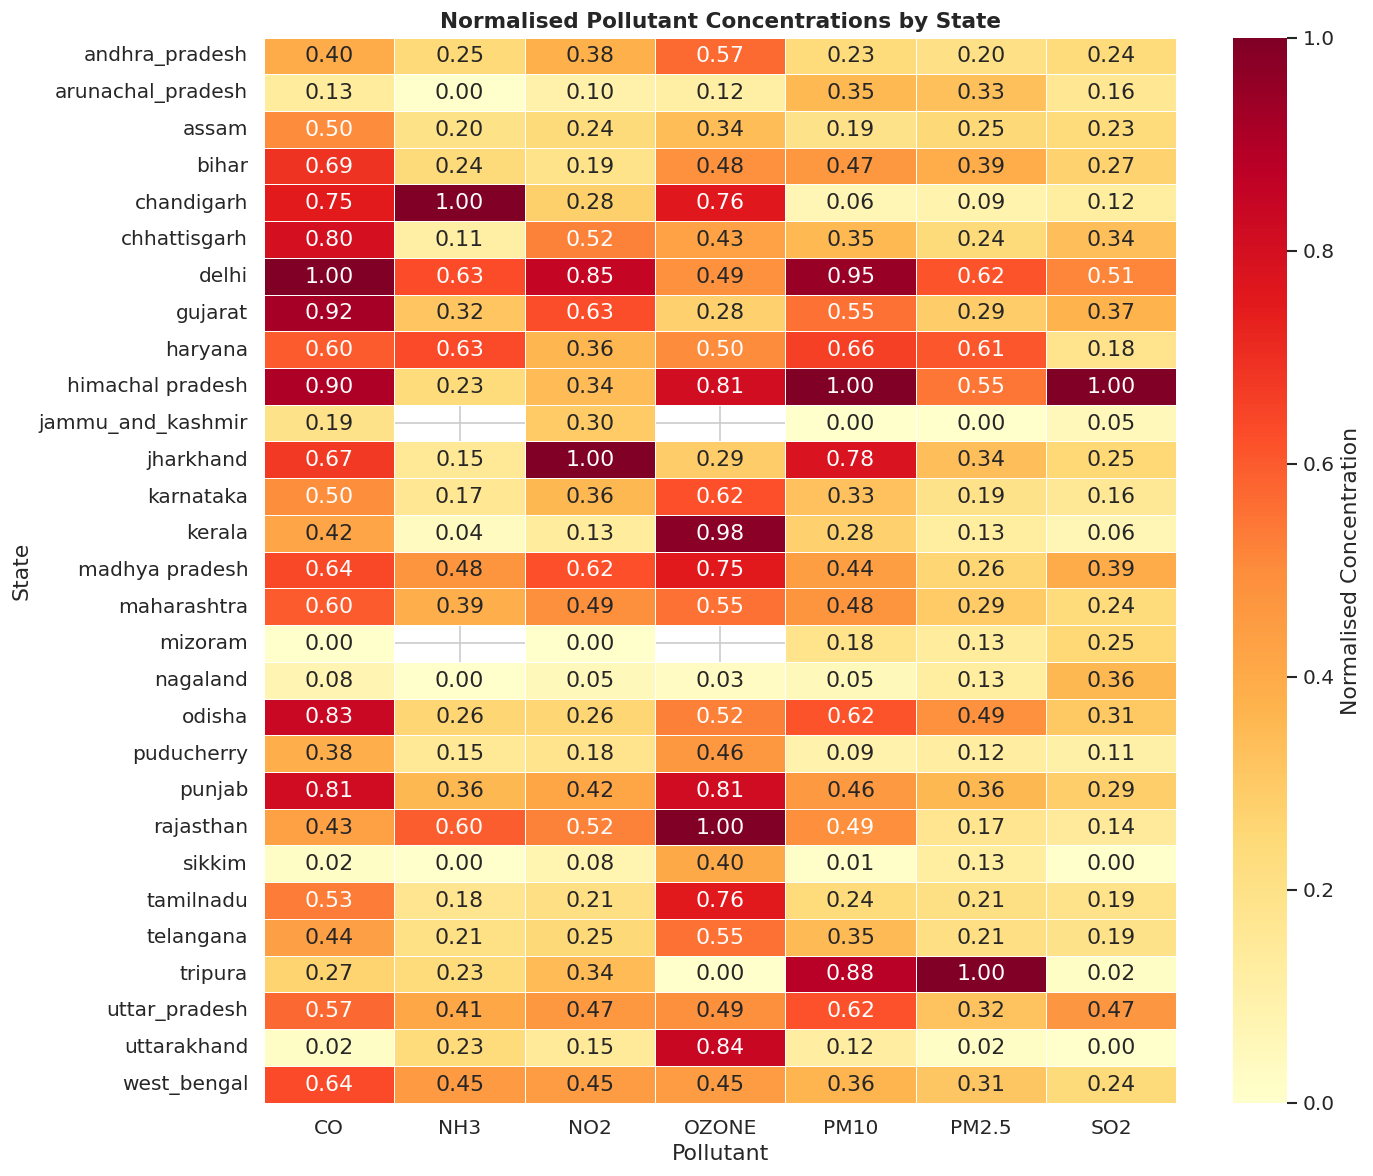

In [16]:
pollutants = ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']

# Build state × pollutant matrix
heat_data = (
    aqi_df
    .groupby(['state_norm', 'pollutant_id'])['pollutant_avg']
    .mean()
    .unstack()
    .reindex(columns=[p for p in pollutants if p in aqi_df['pollutant_id'].unique()])
)
# Normalise each pollutant column to 0-1 for visual comparability
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heat_norm, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            annot=True, fmt='.2f', cbar_kws={'label': 'Normalised Concentration'},
            ax=ax)
ax.set_title('Normalised Pollutant Concentrations by State', fontsize=13, fontweight='bold')
ax.set_xlabel('Pollutant')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('fig4_state_pollutant_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Correlation Analysis
Pearson correlation between `mean_pollutant_avg` and selected socioeconomic/health indicators from NFHS-5.

In [ ]:
from scipy import stats as _stats

SOCIO_FEATURES = [
    'Female population age 6 years and above who ever attended school (%)',
    'Population living in households with electricity (%)',
    'Population living in households that use an improved sanitation facility2 (%)',
    'Households using clean fuel for cooking3 (%)',
    "Women (age 15-49) who are literate4 (%)",
    "Women (age 15-49)  with 10 or more years of schooling (%)",
    'Men age 15 years and above who use any kind of tobacco (%)',
    'Men age 15 years and above who consume alcohol (%)',
    'Infant mortality rate (per 1000 live births)',
    'Under-five mortality rate (per 1000 live births)',
]

corr_df = merged_df[['mean_pollutant_avg'] + SOCIO_FEATURES].copy()
# Coerce all to numeric
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')
corr_df.columns = [
    'Pollution Avg',
    'Female Education (%)',
    'Electricity Access (%)',
    'Improved Sanitation (%)',
    'Clean Cooking Fuel (%)',
    'Women Literacy (%)',
    'Women Schooling ≥10yr (%)',
    'Tobacco Usage — Men (%)',
    'Alcohol Use — Men (%)',
    'Infant Mortality (per 1k)',
    'Under-5 Mortality (per 1k)',
]

corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            ax=ax)
ax.set_title('Pearson Correlation Matrix — Pollution vs Socioeconomic Indicators',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('fig5_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Print correlations with p-values
print('\n=== Pearson r and p-values — Pollution vs Socioeconomic Indicators ===')
print(f'  {"Indicator":<35}  {"r":>7}  {"p-value":>8}  Sig.')
print('  ' + '-'*60)
x_pol = corr_df['Pollution Avg'].dropna()
for col in corr_df.columns[1:]:
    y_feat = corr_df[col].dropna()
    common_idx = x_pol.index.intersection(y_feat.index)
    if len(common_idx) > 3:
        r, p = _stats.pearsonr(x_pol[common_idx], y_feat[common_idx])
        sig = '*' if p < 0.05 else ('†' if p < 0.10 else ' ')
        print(f'  {col:<35}  {r:+.3f}  {p:>8.3f}  {sig}')
print('  (* p<0.05; † p<0.10)')

### 8.1 Scatter Plots for Key Socioeconomic Variables

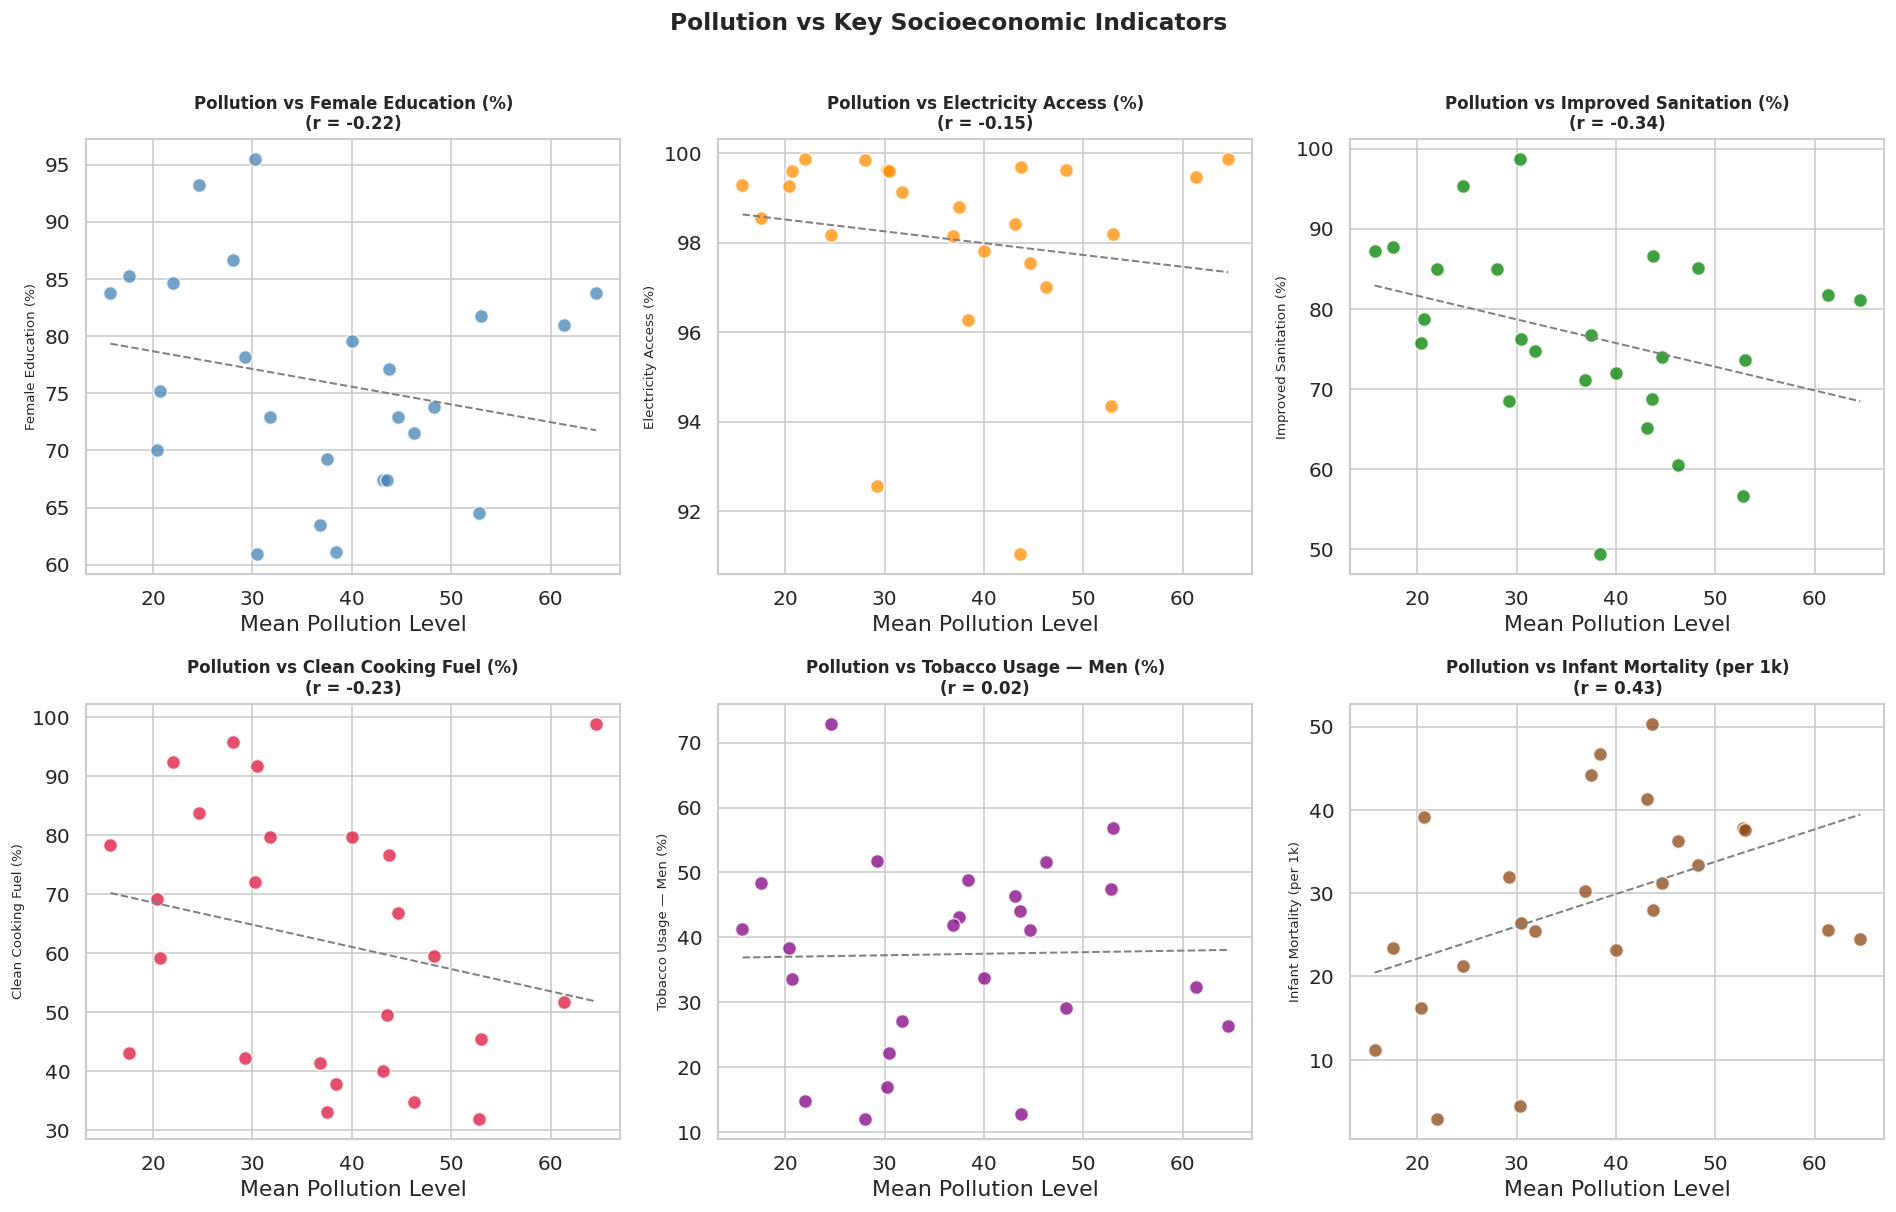

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pairs = [
    ('Female Education (%)',    'steelblue'),
    ('Electricity Access (%)',  'darkorange'),
    ('Improved Sanitation (%)', 'green'),
    ('Clean Cooking Fuel (%)',  'crimson'),
    ('Tobacco Usage — Men (%)', 'purple'),
    ('Infant Mortality (per 1k)', 'saddlebrown'),
]

for ax, (feat, color) in zip(axes, pairs):
    x = corr_df['Pollution Avg']
    y = corr_df[feat]
    ax.scatter(x, y, color=color, alpha=0.75, edgecolors='w', s=70)
    valid = x.notna() & y.notna()
    m, b = np.polyfit(x[valid], y[valid], 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m * xs + b, '--', color='gray', linewidth=1.2)
    r = x.corr(y)
    ax.set_title(f'Pollution vs {feat}\n(r = {r:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean Pollution Level')
    ax.set_ylabel(feat, fontsize=8)

plt.suptitle('Pollution vs Key Socioeconomic Indicators', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_scatter_plots.png', bbox_inches='tight')
plt.show()

## 9. K-Means Clustering — State Pollution-Vulnerability Profiles
States are clustered using `mean_pollutant_avg` together with three structural indicators (electricity access, sanitation, female education) to identify distinct pollution-vulnerability profiles.

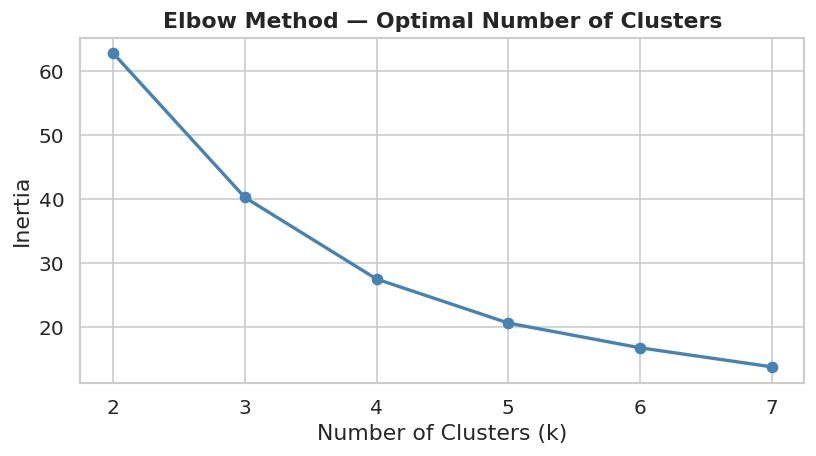

In [19]:
CLUSTER_FEATURES = [
    'mean_pollutant_avg',
    'Electricity Access (%)',
    'Improved Sanitation (%)',
    'Female Education (%)',
]

cluster_data = corr_df[['Pollution Avg', 'Electricity Access (%)',
                          'Improved Sanitation (%)', 'Female Education (%)']].dropna().copy()
states_clust = merged_df.loc[cluster_data.index, 'state_norm']

scaler_c = StandardScaler()
X_clust = scaler_c.fit_transform(cluster_data)

# Elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('fig7_elbow.png', bbox_inches='tight')
plt.show()

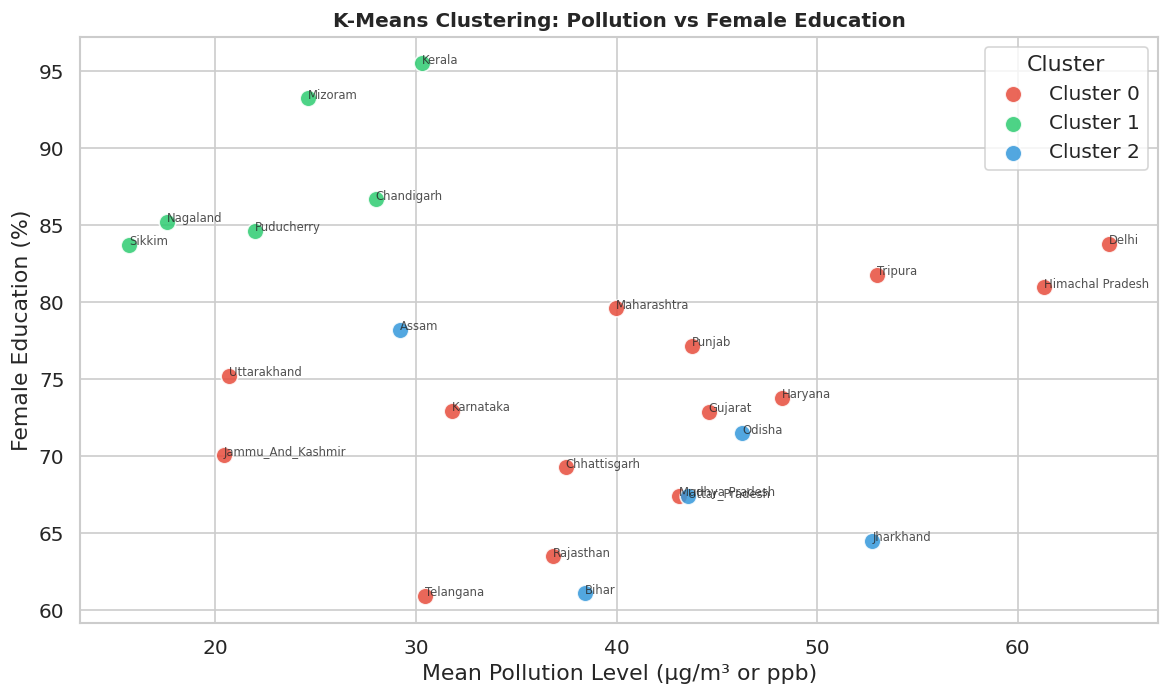


=== Cluster Profiles ===
         Pollution Avg  Electricity Access (%)  Improved Sanitation (%)  \
Cluster                                                                   
0                41.15                   98.94                    76.61   
1                23.03                   99.22                    89.82   
2                42.04                   94.24                    60.76   

         Female Education (%)  
Cluster                        
0                       73.52  
1                       88.16  
2                       68.54  

=== States per Cluster ===
Cluster 0: ['chhattisgarh', 'delhi', 'gujarat', 'haryana', 'himachal pradesh', 'jammu_and_kashmir', 'karnataka', 'madhya pradesh', 'maharashtra', 'punjab', 'rajasthan', 'telangana', 'tripura', 'uttarakhand']
Cluster 1: ['chandigarh', 'kerala', 'mizoram', 'nagaland', 'puducherry', 'sikkim']
Cluster 2: ['assam', 'bihar', 'jharkhand', 'odisha', 'uttar_pradesh']


In [20]:
# Fit with k=3
OPTIMAL_K = 3
km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_data['Cluster'] = km.fit_predict(X_clust)
cluster_data['State'] = states_clust.values

# Visualise clusters
fig, ax = plt.subplots(figsize=(10, 6))
palette_c = ['#e74c3c', '#2ecc71', '#3498db']
for cl in range(OPTIMAL_K):
    sub = cluster_data[cluster_data['Cluster'] == cl]
    ax.scatter(sub['Pollution Avg'], sub['Female Education (%)'],
               label=f'Cluster {cl}', color=palette_c[cl],
               s=100, alpha=0.85, edgecolors='w')
    for _, row in sub.iterrows():
        ax.annotate(row['State'].title(), (row['Pollution Avg'], row['Female Education (%)']),
                    fontsize=7, ha='left', alpha=0.8)
ax.set_title('K-Means Clustering: Pollution vs Female Education', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Pollution Level (µg/m³ or ppb)')
ax.set_ylabel('Female Education (%)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('fig8_kmeans_clusters.png', bbox_inches='tight')
plt.show()

print('\n=== Cluster Profiles ===')
profile = cluster_data.groupby('Cluster')[['Pollution Avg', 'Electricity Access (%)',
                                           'Improved Sanitation (%)', 'Female Education (%)']].mean().round(2)
print(profile)

print('\n=== States per Cluster ===')
for cl in range(OPTIMAL_K):
    states_in = cluster_data[cluster_data['Cluster'] == cl]['State'].values
    print(f'Cluster {cl}: {list(states_in)}')

## 10. Machine Learning — Predicting State-Level Pollution
### 10.1 Feature Selection
Features are selected based on domain relevance and exploratory correlation findings.

In [21]:
ML_FEATURES = [
    'Female population age 6 years and above who ever attended school (%)',
    'Population living in households with electricity (%)',
    'Population living in households that use an improved sanitation facility2 (%)',
    'Households using clean fuel for cooking3 (%)',
    "Women (age 15-49) who are literate4 (%)",
    "Women (age 15-49)  with 10 or more years of schooling (%)",
    'Men age 15 years and above who use any kind of tobacco (%)',
    'Men age 15 years and above who consume alcohol (%)',
]

model_df = merged_df[['mean_pollutant_avg'] + ML_FEATURES].copy()
# Ensure all feature columns are numeric (some excel columns may be object)
for col in ML_FEATURES + ['mean_pollutant_avg']:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
model_df = model_df.dropna()
X = model_df[ML_FEATURES]
y = model_df['mean_pollutant_avg']

print(f'Modelling on {len(model_df)} states with {len(ML_FEATURES)} features.')

Modelling on 25 states with 8 features.


### 10.2 Train / Test Split and Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

### 10.3 Model Training and Comparison

In [ ]:
models = {
    'Linear Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ]),
    'Ridge Regression'  : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0)),
    ]),
    'Random Forest'     : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)),
    ]),
    'Gradient Boosting' : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)),
    ]),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    # cross_val_score on the full pipeline avoids data leakage
    cv_r2  = cross_val_score(pipe, X, y, cv=kfold, scoring='r2').mean()
    results[name] = {
        'MAE'   : round(mean_absolute_error(y_test, y_pred), 3),
        'RMSE'  : round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        'R²'    : round(r2_score(y_test, y_pred), 3),
        'CV R²' : round(cv_r2, 3),
    }

results_df = pd.DataFrame(results).T
print('=== Model Comparison ===')
print(results_df.to_string())

### 10.4 Feature Importance (Random Forest)

In [ ]:
rf_model = models['Random Forest']['model']

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

# Shorten labels for readability
short_labels = {
    'Female population age 6 years and above who ever attended school (%)' : 'Female School Attendance',
    'Population living in households with electricity (%)'                   : 'Electricity Access',
    'Population living in households that use an improved sanitation facility2 (%)': 'Improved Sanitation',
    'Households using clean fuel for cooking3 (%)'                          : 'Clean Cooking Fuel',
    "Women (age 15-49) who are literate4 (%)"                               : 'Women Literacy',
    "Women (age 15-49)  with 10 or more years of schooling (%)"             : 'Women Schooling ≥10yr',
    'Men age 15 years and above who use any kind of tobacco (%)'            : 'Tobacco Use (Men)',
    'Men age 15 years and above who consume alcohol (%)'                    : 'Alcohol Use (Men)',
}
importance.index = [short_labels.get(i, i) for i in importance.index]

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Blues_d', len(importance))
importance.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('fig9_feature_importance.png', bbox_inches='tight')
plt.show()

### 10.5 Actual vs Predicted Pollution (Best Model)

In [ ]:
# Use Random Forest (typically best)
best_model_name = max(results, key=lambda k: results[k]['R²'])
best_model = models[best_model_name]
y_best_pred = best_model.predict(X_test_s)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_best_pred, color='steelblue', s=80, alpha=0.8, edgecolors='w')
lims = [min(y_test.min(), y_best_pred.min()) - 2,
        max(y_test.max(), y_best_pred.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Actual vs Predicted — {best_model_name}', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual Mean Pollution Level')
ax.set_ylabel('Predicted Mean Pollution Level')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

print(f'Best model : {best_model_name}')
print(f'R²  : {results[best_model_name]["R²"]}')
print(f'MAE : {results[best_model_name]["MAE"]}')
print(f'RMSE: {results[best_model_name]["RMSE"]}')

### 10.6 Linear Regression Coefficients

In [ ]:
lr_model = models['Linear Regression']['model']

coeff = pd.Series(lr_model.coef_, index=X.columns)
coeff.index = [short_labels.get(i, i) for i in coeff.index]
coeff = coeff.sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in coeff]
coeff.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression Coefficients\n(Standardised Features → Pollution)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value (Standardised)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('fig11_lr_coefficients.png', bbox_inches='tight')
plt.show()

## 11. Key Insights and Conclusions
### 11.1 Pollution Landscape
- **PM10 and PM2.5** are the dominant pollutants across Indian states, with mean levels of 96 µg/m³ and 77 µg/m³ respectively — both substantially exceeding WHO guidelines (PM10: 15 µg/m³; PM2.5: 5 µg/m³ annual average).
- **Delhi** and **Himachal Pradesh** record the highest composite pollution levels. Northern and central Indian states consistently appear in the top-pollution tier.
- Approximately **57%** of all monitoring readings fall in the 'Good' or 'Satisfactory' category, yet ~17% register 'Moderate' and ~20% 'Poor' or worse — indicating widespread public-health risk.

### 11.2 Socioeconomic Correlates
- **Negative correlations** are observed between pollution levels and female education, electricity access, improved sanitation, and clean cooking fuel — suggesting that higher development indices partially co-occur with lower pollution exposure at the state level. However, the relationships are non-linear and confounded by urbanisation.
- **Tobacco and alcohol use** show weak positive correlations with pollution, likely reflecting shared socioeconomic risk environments rather than direct causation.

### 11.3 Clustering
Three distinct state clusters emerge:
- **Cluster 0 (High Pollution / Lower Development):** States with elevated pollution and relatively lower access to electricity, sanitation, and education — indicating compounded environmental and social vulnerability.
- **Cluster 1 (Moderate Pollution / Mixed Development):** Mid-range states with heterogeneous development profiles.
- **Cluster 2 (Lower Pollution / Higher Development):** States combining lower pollution exposure with stronger socioeconomic indicators.

### 11.4 Predictive Modelling
- Ensemble methods (Random Forest, Gradient Boosting) outperform linear models on this small dataset (n = 29 states), though all R² values should be interpreted cautiously.
- **Clean cooking fuel access** and **electricity access** emerge as the most influential features in the Random Forest model, indicating that energy transition policies may have a meaningful co-benefit for air quality.

### 11.5 Study Limitations
- The merged dataset covers only 22 states due to naming inconsistencies between CPCB and NFHS-5 records; expanding harmonisation would increase statistical power.
- AQI data represents a single snapshot; longitudinal data would enable causal inference.
- NFHS-5 indicators are 2019–21 estimates; temporal alignment with AQI readings is approximate.
- A sample of n = 29 states is insufficient for robust ML generalisation; results should be treated as exploratory.

---
## Appendix: Environment Information

In [27]:
import sys, sklearn
print('Python   :', sys.version)
print('pandas   :', pd.__version__)
print('numpy    :', np.__version__)
print('sklearn  :', sklearn.__version__)

Python   : 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
pandas   : 3.0.1
numpy    : 2.4.3
sklearn  : 1.8.0
